## **Import Libraries**

In [ ]:
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

## **Phase 1 - Load Dataset**

In [2]:
df = pd.read_csv("house_prices.csv",low_memory=False)
df.head(10)

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN
5,5,1 BHK Ready to Occupy Flat for sale in Virat A...,Creatively planned and constructed is a 1 BHK ...,45 Lac,6618.0,thane,NaN,Ready to Move,2 out of 7,Resale,...,East,"Garden/Park, Main Road",Virat Aangan,1,1,NaN,Co-operative Society,680 sqft,NaN,NaN
6,6,1 BHK Ready to Occupy Flat for sale Mumbra,This magnificent 1 BHK Flat is available for s...,16.5 Lac,2538.0,thane,550 sqft,Ready to Move,4 out of 5,Resale,...,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
7,7,1 BHK Ready to Occupy Flat for sale Kalwa,Creatively planned and constructed is a 1 BHK ...,60 Lac,10435.0,thane,NaN,Ready to Move,Ground out of 7,Resale,...,NaN,NaN,NaN,1,NaN,NaN,NaN,575 sqft,NaN,NaN
8,8,1 BHK Ready to Occupy Flat for sale Kalwa,Discover this immaculate 1 BHK flat for sale a...,60 Lac,10000.0,thane,NaN,Ready to Move,Ground out of 2,Resale,...,NaN,NaN,NaN,1,NaN,NaN,Co-operative Society,600 sqft,NaN,NaN
9,9,3 BHK Ready to Occupy Flat for sale in Pride P...,One can find this stunning 3 BHK flat for sale...,1.60 Cr,11150.0,thane,900 sqft,Ready to Move,3 out of 27,Resale,...,East,Garden/Park,Pride Palms,3,1,1 Covered,Freehold,NaN,NaN,NaN


In [3]:
print("Dataset Shape:",df.shape)

Dataset Shape: (187531, 21)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [5]:
missing_values = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_values.to_frame("Missing %")

,Missing %
Plot Area,100.000000
Dimensions,100.000000
Society,58.485264
Super Area,57.422506
Car Parking,55.114621
overlooking,43.425354
Carpet Area,43.018488
facing,37.451408
Ownership,34.936624
Balcony,26.094352


In [6]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
text_columns = df.select_dtypes(exclude="number").columns.tolist()

In [7]:
print("Numeric Columns:", numeric_columns)

Numeric Columns: ['Index', 'Price (in rupees)', 'Dimensions', 'Plot Area']


In [8]:
print("Text Columns:", text_columns)

Text Columns: ['Title', 'Description', 'Amount(in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area']


## **Phase 2 - Data Cleaning**

### **Clean Price**

In [9]:
def parse_amount(value):
    if not isinstance(value, str):
        return np.nan

    value = value.lower().strip().replace(",", "")
    number = re.search(r"\d+(?:\.\d+)?", value)

    if number is None:
        return np.nan

    number = float(number.group())

    if "lac" in value or "lakh" in value:
        return number * 100000
    elif "cr" in value or "crore" in value:
        return number * 10000000
    else:
        return number

In [10]:
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df[["Amount(in rupees)","price_clean"]].head()

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0


### **Clean Area**

In [12]:
def parse_area(value):
    if not isinstance(value, str):
        return np.nan

    value = value.lower().strip().replace(",", "")
    number = re.search(r"\d+(?:\.\d+)?", value)

    if number is None:
        return np.nan

    area = float(number.group())

    if "sqyrd" in value or "sq yd" in value:
        return area * 9
    elif "sqm" in value or "sq m" in value:
        return area * 10.764
    elif "acre" in value:
        return area * 43560
    elif "marla" in value:
        return area * 272.25
    elif "kanal" in value:
        return area * 5445
    elif "ground" in value:
        return area * 2400
    elif "cent" in value:
        return area * 435.6
    elif "hectare" in value:
        return area * 107639
    elif "sqft" in value or "sq ft" in value:
        return area
    else:
        return np.nan

In [13]:
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])
df[["Carpet Area", "Super Area", "carpet_area_sqft"]].head()

,Carpet Area,Super Area,carpet_area_sqft
0,500 sqft,NaN,500.0
1,473 sqft,NaN,473.0
2,779 sqft,NaN,779.0
3,530 sqft,NaN,530.0
4,635 sqft,NaN,635.0


### **Clean Floor and Property Details**

In [14]:
def parse_floor(value):
    if not isinstance(value, str):
        return np.nan

    value = value.lower().strip()

    if "lower basement" in value:
        return -2
    elif "upper basement" in value or value.startswith("basement"):
        return -1
    elif value.startswith("ground"):
        return 0

    number = re.search(r"-?\d+", value)
    return float(number.group()) if number else np.nan

In [15]:
def parse_count(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()
    number = re.search(r"\d+(?:\.\d+)?", value)

    if number is None:
        return np.nan

    number = float(number.group())

    if value.startswith(">"):
        return number + 1

    return number

In [16]:
df["floor_num"] = df["Floor"].apply(parse_floor)
df["bathroom"] = df["Bathroom"].apply(parse_count)
df["balcony"] = df["Balcony"].apply(parse_count)
df["car_parking"] = df["Car Parking"].apply(parse_count).fillna(0)
df[["Floor", "floor_num", "Bathroom", "bathroom", "Balcony", "balcony"]].head()

,Floor,floor_num,Bathroom,bathroom,Balcony,balcony
0,10 out of 11,10.0,1,1.0,2,2.0
1,3 out of 22,3.0,2,2.0,NaN,NaN
2,10 out of 29,10.0,2,2.0,NaN,NaN
3,1 out of 3,1.0,1,1.0,1,1.0
4,20 out of 42,20.0,2,2.0,NaN,NaN


### **Group Categories and Remove Outliers**

In [17]:
top_locations = df["location"].value_counts().head(50).index
top_societies = df["Society"].value_counts().head(50).index
df["location_grouped"] = df["location"].apply(lambda x: x if x in top_locations else "other")
df["society_grouped"] = df["Society"].apply(lambda x: x if x in top_societies else "other")

In [18]:
print("Location Groups:",df["location_grouped"].nunique())

Location Groups: 51


In [19]:
print("Society Groups:",df["society_grouped"].nunique())

Society Groups: 51


In [20]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]

lower_limit = df["price_per_sqft"].quantile(0.01)
upper_limit = df["price_per_sqft"].quantile(0.99)

before = df.shape[0]

df = df[df["price_per_sqft"].between(lower_limit, upper_limit)| df["price_per_sqft"].isna()]
after = df.shape[0]

print("Rows Before:", before)
print("Rows After:", after)
print("Removed Rows:", before - after)

Rows Before: 177847
Rows After: 174380
Removed Rows: 3467


## **EDA**

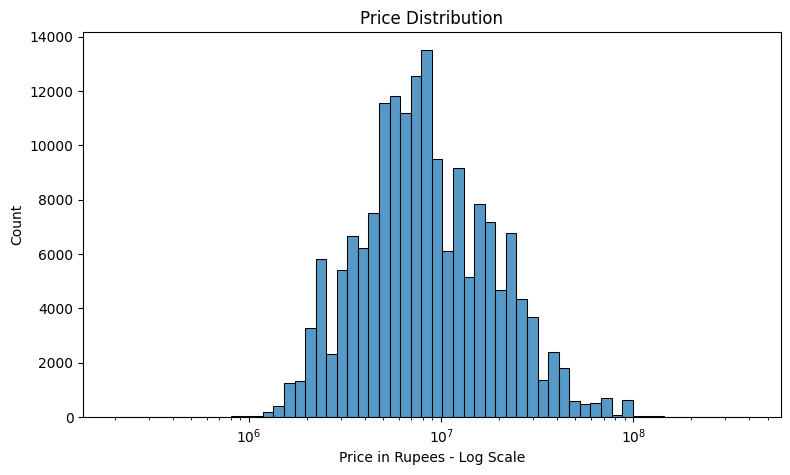

In [21]:
plt.figure(figsize=(9, 5))
sns.histplot(df["price_clean"], bins=60, log_scale=True)
plt.title("Price Distribution")
plt.xlabel("Price in Rupees - Log Scale")
plt.show()

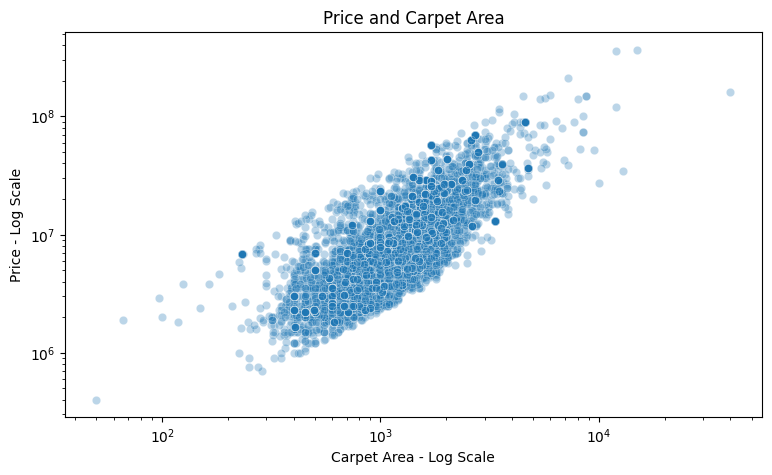

In [22]:
area_data = df.dropna(subset=["carpet_area_sqft"])
area_sample = area_data.sample(n=min(15000, len(area_data)), random_state=42)

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=area_sample,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.3
)
plt.xscale("log")
plt.yscale("log")
plt.title("Price and Carpet Area")
plt.xlabel("Carpet Area - Log Scale")
plt.ylabel("Price - Log Scale")
plt.show()

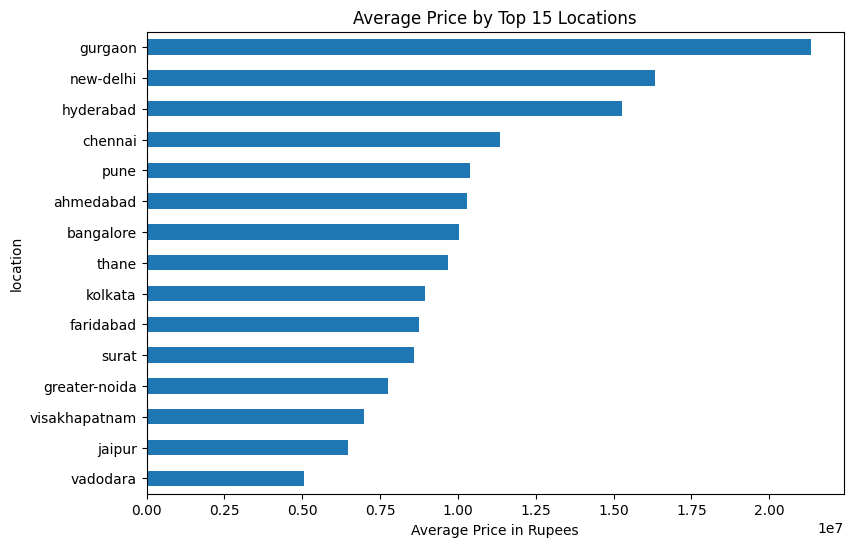

In [23]:
top_15_locations = df["location"].value_counts().head(15).index

average_price = (
    df[df["location"].isin(top_15_locations)]
    .groupby("location")["price_clean"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(9, 6))
average_price.plot(kind="barh")
plt.title("Average Price by Top 15 Locations")
plt.xlabel("Average Price in Rupees")
plt.show()

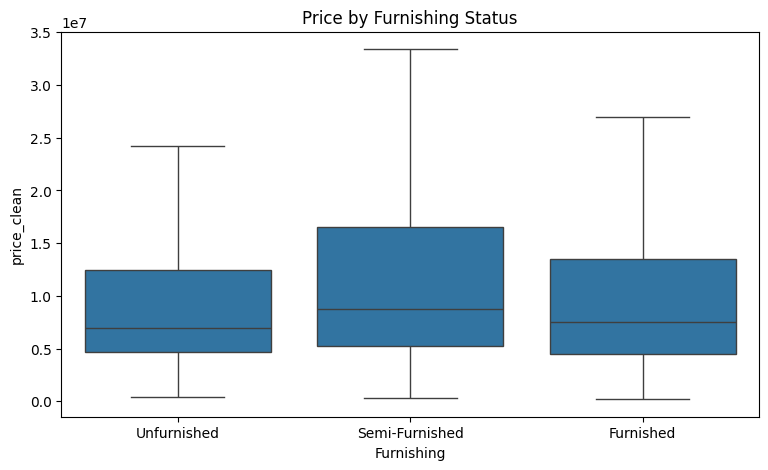

In [24]:
plot_data = df[df["bathroom"].between(1, 6)]

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=plot_data,
    x="Furnishing",
    y="price_clean",
    showfliers=False
)
plt.title("Price by Furnishing Status")
plt.show()

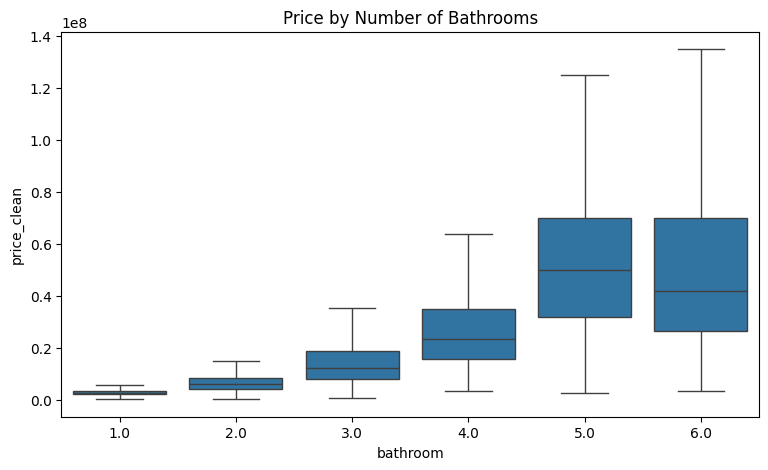

In [25]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=plot_data,
    x="bathroom",
    y="price_clean",
    showfliers=False
)
plt.title("Price by Number of Bathrooms")
plt.show()

# Data Preprocessing

In [ ]:
num_features = ["carpet_area_sqft","floor_num","bathroom","balcony","car_parking"]
cat_features = ["location_grouped","society_grouped","Furnishing","Transaction","Ownership","facing"]

In [27]:
x = df[num_features + cat_features]
y = df["price_clean"]

In [28]:
x.head()

,carpet_area_sqft,floor_num,bathroom,balcony,car_parking,location_grouped,society_grouped,Furnishing,Transaction,Ownership,facing
0,500.0,10.0,1.0,2.0,0.0,thane,other,Unfurnished,Resale,NaN,NaN
1,473.0,3.0,2.0,NaN,1.0,thane,other,Semi-Furnished,Resale,Freehold,East
2,779.0,10.0,2.0,NaN,1.0,thane,other,Unfurnished,Resale,Freehold,East
3,530.0,1.0,1.0,1.0,0.0,thane,other,Unfurnished,Resale,NaN,NaN
4,635.0,20.0,2.0,NaN,1.0,thane,other,Unfurnished,Resale,Co-operative Society,West


In [29]:
y.head()

0     4200000.0
1     9800000.0
2    14000000.0
3     2500000.0
4    16000000.0
Name: price_clean, dtype: float64

In [ ]:
num_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
cat_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("onehot", OneHotEncoder(handle_unknown="ignore"))])

In [ ]:
preprocessor = ColumnTransformer(transformers=[("num", num_pipeline, num_features),("cat", cat_pipeline, cat_features)])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((139504, 11), (34876, 11), (139504,), (34876,))

## **Linear Regression**

In [ ]:
model1 = Pipeline(steps=[("preprocessor", preprocessor),("model", LinearRegression())])
model1.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
model1.score(x_train, y_train) * 100

76.39225292062126

In [36]:
model1.score(x_test, y_test) * 100

73.66983773868212

## **Random Forest**

In [37]:
model2 = Pipeline(steps=[("preprocessor", preprocessor),("model", RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1))])
model2.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
model2.score(x_train, y_train) * 100

99.00755815981788

In [39]:
model2.score(x_test, y_test) * 100

92.87034382927277

## **Evaluate the models**

In [40]:
prediction1 = model1.predict(x_test)
prediction2 = model2.predict(x_test)

In [41]:
mae1 = mean_absolute_error(y_test, prediction1)
rmse1 = mean_squared_error(y_test, prediction1) ** 0.5
r2_1 = r2_score(y_test, prediction1)

mae2 = mean_absolute_error(y_test, prediction2)
rmse2 = mean_squared_error(y_test, prediction2) ** 0.5
r2_2 = r2_score(y_test, prediction2)

In [42]:
print("Linear Regression")
print("MAE:",mae1)
print("RMSE:",rmse1)
print("R2:",r2_1)

Linear Regression
MAE: 3219666.9991444102
RMSE: 6295422.49909048
R2: 0.7366983773868212


In [43]:
print("Random Forest")
print("MAE:",mae2)
print("RMSE:",rmse2)
print("R2:",r2_2)

Random Forest
MAE: 919327.0254378223
RMSE: 3275913.3607880427
R2: 0.9287034382927277


## **Compare the models**

In [44]:
results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest"],
    "MAE": [mae1,mae2],
    "RMSE": [rmse1,rmse2],
    "R2": [r2_1,r2_2]
})

results.sort_values("RMSE")

,Model,MAE,RMSE,R2
1,Random Forest,9.193270e+05,3.275913e+06,0.928703
0,Linear Regression,3.219667e+06,6.295422e+06,0.736698


In [45]:
best_model = results.sort_values("RMSE").iloc[0]["Model"]

if best_model == "Linear Regression":
    model = model1
    prediction = prediction1
else:
    model = model2
    prediction = prediction2

print("Best Model:", best_model)

Best Model: Random Forest


## **Predicted and Actual Prices**

In [46]:
plot_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": prediction
})

plot_results = plot_results[
    (plot_results["Actual"] > 0)
    & (plot_results["Predicted"] > 0)
]

plot_results = plot_results.sample(
    n=min(15000, len(plot_results)),
    random_state=42
)

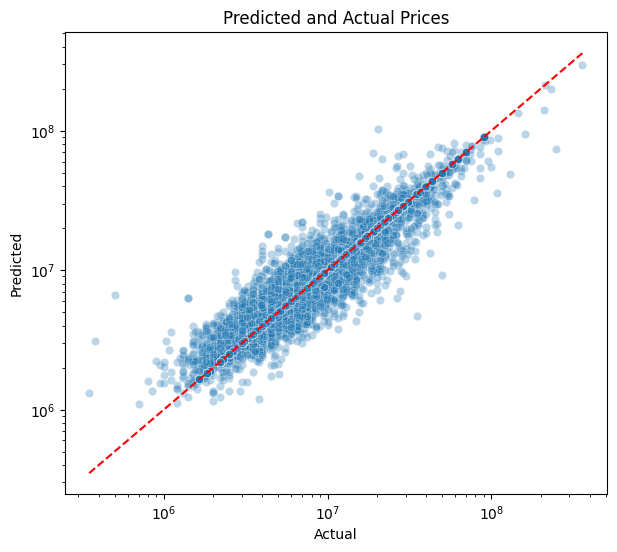

In [47]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=plot_results,
    x="Actual",
    y="Predicted",
    alpha=0.3
)

minimum = plot_results.min().min()
maximum = plot_results.max().max()

plt.plot([minimum, maximum], [minimum, maximum], "r--")
plt.xscale("log")
plt.yscale("log")
plt.title("Predicted and Actual Prices")
plt.show()

## **Fold Cross Validation**

In [ ]:
cv_scores = -cross_val_score(model1,x,y,cv=5,scoring="neg_mean_absolute_error",n_jobs=-1)
print("MAE for Each Fold:", cv_scores)
print("Average MAE:", cv_scores.mean())

MAE for Each Fold: [4226094.29190935 6079678.62260556 2854068.54225161 6258046.39489707
 5445932.37040543]
Average MAE: 4972764.044413801


## **Save the model**

In [49]:
joblib.dump(model, "house_price.pkl")

locations = sorted(df["location_grouped"].unique().tolist())

with open("locations.json", "w") as file:
    json.dump(locations, file, indent=4)

## **Test the saved model**

In [50]:
loaded_model = joblib.load("house_price.pkl")

inputs = x_test.iloc[[0]]
output = loaded_model.predict(inputs)

print("The predicted price is:", output[0])
print("The actual price is:", y_test.iloc[0])

inputs

The predicted price is: 5600000.0
The actual price is: 5600000.0


,carpet_area_sqft,floor_num,bathroom,balcony,car_parking,location_grouped,society_grouped,Furnishing,Transaction,Ownership,facing
6818,839.592,1.0,2.0,2.0,0.0,ahmedabad,other,Semi-Furnished,Resale,Freehold,East
